## LIBRARIES

In [ ]:
import tensorflow as tf
from joblib import load

# Imports controller model from models.py
from models import ScaledController

# Imports main training function from trainer.py
from trainer import train_and_save_controller

## MACIAL

In [ ]:
print("--- Generating input data ---")

# Paths
ICE_folder = os.path.join('CTTC_models', 'ONNX', 'ICE')
PG_folder = os.path.join('CTTC_models', 'ONNX', 'PG')
tf_model = 'model.h5'

# Dummy Data (Simulating CSV row)
input_data = {
    'ICE_Speed_rpm': 2000.0, 
    'fuel_mg': 35.0, 
    'T_amb_K': 298.0, 
    'p_amb_bar': 1.013
}
# Convert to Numpy so it is the exact same source for both
x_source = np.array([[input_data['ICE_Speed_rpm'], input_data['fuel_mg'], 
                      input_data['T_amb_K'], input_data['p_amb_bar']]], dtype='float32')


# ==============================================================================
# 3. EXECUTION METHOD A: "NEW CODE" (CLASS)
# ==============================================================================
print("\n🔵 Executing METHOD A (New Class)...")

# Setup
model_A = setup_transition_function_model(ICE_folder, PG_folder)

## MODELS

In [ ]:
scaler = load("../src/escalados/gbm_v1.lib")
scaler_params = {
    "data_min": scaler.data_min_,   # 6 values
    "data_max": scaler.data_max_,   # 6 values
    "scale":    scaler.scale_,      # 6 values  (1/(max-min) or 2/(max-min))
    "min":      scaler.min_,        # 6 values  (offset)
}

controller = ScaledController(scaler_params, units=128, alpha=1000)

2025-10-03 11:28:46.247669: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-03 11:28:46.273592: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:

# Example parameters
epochs     = 10000
alpha, beta, gamma = 1.0, 0, 0

NOx_mean = tf.constant(0.0001663531, dtype=tf.float32)
CO_mean  = tf.constant(0.0013611736, dtype=tf.float32)
# For velocity term, divide by 1.0 (or change to something more realistic if you have standard deviation)
vel_norm = tf.constant(1.0, dtype=tf.float32)

alpha = alpha/vel_norm
beta = beta/NOx_mean
gamma = gamma/CO_mean



name       = "V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best"


# Execute training and saving
out_dir, losses = train_and_save_controller(
    epochs,
    alpha, beta, gamma,
    name,
    ruta_ICE="../src/models_markus/ICE_Model_Update_01",
    ruta_PG="../src/models_markus/PG_Model_M1.1_without_EM1_Torque",
    controller=controller,
    learning_rate=1e-4,
    output_root="models",
    clipping= True,
    evalue= True,
    vel_target = 75.,
    plateau_patience = 10,
    early_stop_patience = 24,
    warmup_steps = 600,
    good_loss =0.05,
    profile_training=True 
    )




print("All done in:", out_dir)

🔍 Intentando cargar modelo desde: ../src/models_markus/ICE_Model_Update_01/model.h5
🔍 Intentando cargar modelo desde: ../src/models_markus/PG_Model_M1.1_without_EM1_Torque/model.h5


/home/usuaris.new/artur.aubach/Antic_RL_Cotxe/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/usuaris.new/artur.aubach/Antic_RL_Cotxe/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/usuaris.new/artur.aubach/Antic_RL_Cotxe/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


[Seed 0] loss corto: 223.0576
[Seed 1] loss corto: 27.4257
[Seed 2] loss corto: 10.1168
⚡ Usando semilla con loss corto mejor: 10.1168
Epoch 1/10000 — Loss mitjana: 8.6158
Epoch 2/10000 — Loss mitjana: 3.9378
Epoch 3/10000 — Loss mitjana: 0.8548
Epoch 4/10000 — Loss mitjana: 0.6142
Epoch 5/10000 — Loss mitjana: 11.4785
Epoch 6/10000 — Loss mitjana: 2.8135
Epoch 7/10000 — Loss mitjana: 5.9315
Epoch 8/10000 — Loss mitjana: 0.7469
Epoch 9/10000 — Loss mitjana: 1.0398
Epoch 10/10000 — Loss mitjana: 2.5730
Epoch 11/10000 — Loss mitjana: 13.0917
Epoch 12/10000 — Loss mitjana: 0.1998
Epoch 13/10000 — Loss mitjana: 0.5879
Epoch 14/10000 — Loss mitjana: 0.5168
Epoch 15/10000 — Loss mitjana: 4.0124
Epoch 16/10000 — Loss mitjana: 392.3536
Epoch 17/10000 — Loss mitjana: 2.5046
Epoch 18/10000 — Loss mitjana: 6.2998
Epoch 19/10000 — Loss mitjana: 2.7214
Epoch 20/10000 — Loss mitjana: 3.7034
Epoch 21/10000 — Loss mitjana: 1.2472
Epoch 22/10000 — Loss mitjana: 2.1395
  ↳ Restaurats els millors pesos a

INFO:tensorflow:Assets written to: models/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_600warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best/assets


✔ Model guardat en models/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_600warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best
✔ Gràfic de pèrdua guardat en models/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_600warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/loss.png
─── Pérdida media últimas 200 iteraciones ───
|70-vel|: 1.4919
NOx    : 0.0397
CO     : 0.0009
✔ Gràfic interactiu guardat en models/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_600warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/traj_final.html
Todo listo en: models/V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_600warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g


In [3]:
scaler = load("../src/escalados/gbm_v2.lib")
scaler_params = {
    "data_min": scaler.data_min_,   # 6 valores
    "data_max": scaler.data_max_,   # 6 valores
    "scale":    scaler.scale_,      # 6 valores  (1/(max-min) ó 2/(max-min))
    "min":      scaler.min_,        # 6 valores  (desplazamiento)
}

controller = ScaledController(scaler_params, units=128, alpha=1000)

In [4]:

# Parámetros de ejemplo
epochs     = 10000
alpha, beta, gamma = 1.0, 0, 0

NOx_mean = tf.constant(0.0001663531, dtype=tf.float32)
CO_mean  = tf.constant(0.0013611736, dtype=tf.float32)
# Para el término de velocidad dividimos por 1.0 (o cambia a algo más realista si tienes desviación típica)
vel_norm = tf.constant(1.0, dtype=tf.float32)

alpha = alpha/vel_norm
beta = beta/NOx_mean
gamma = gamma/CO_mean



name       = "111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best"


# Ejecutar entrenamiento y guardado
# Ejecutar entrenamiento y guardado
out_dir, losses = train_and_save_controller(
    epochs,
    alpha, beta, gamma,
    name,
    ruta_ICE="../src/models_markus/ICE_Model_Update_01",
    ruta_PG="../src/models_markus/PG_Model_M1.1_without_EM1_Torque",
    controller=controller,
    learning_rate=1e-4,
    output_root="models",
    clipping= True,
    evalue= True,
    vel_target = 75.,
    plateau_patience = 10,
    early_stop_patience = 24,
    warmup_steps = 300,
    good_loss =0.05,

)


print("Todo listo en:", out_dir)


🔍 Intentando cargar modelo desde: ../src/models_markus/ICE_Model_Update_01/model.h5
🔍 Intentando cargar modelo desde: ../src/models_markus/PG_Model_M1.1_without_EM1_Torque/model.h5


/home/usuaris.new/artur.aubach/Antic_RL_Cotxe/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/usuaris.new/artur.aubach/Antic_RL_Cotxe/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/usuaris.new/artur.aubach/Antic_RL_Cotxe/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


[Seed 0] loss corto: 155.2527
[Seed 1] loss corto: 251.6789
[Seed 2] loss corto: 4.7407
⚡ Usando semilla con loss corto mejor: 4.7407
Epoch 1/10000 — Loss mitjana: 2.3063
Epoch 2/10000 — Loss mitjana: 1.5581
Epoch 3/10000 — Loss mitjana: 4.4837
Epoch 4/10000 — Loss mitjana: 0.7136
Epoch 5/10000 — Loss mitjana: 1.0147
Epoch 6/10000 — Loss mitjana: 0.8459
Epoch 7/10000 — Loss mitjana: 2.1850
Epoch 8/10000 — Loss mitjana: 0.3423
Epoch 9/10000 — Loss mitjana: 0.5493
Epoch 10/10000 — Loss mitjana: 3.3132
Epoch 11/10000 — Loss mitjana: 5.7826
Epoch 12/10000 — Loss mitjana: 7.4184
Epoch 13/10000 — Loss mitjana: 0.8382
Epoch 14/10000 — Loss mitjana: 1.0948
Epoch 15/10000 — Loss mitjana: 5.5159
Epoch 16/10000 — Loss mitjana: 1.8095
Epoch 17/10000 — Loss mitjana: 7.6782
Epoch 18/10000 — Loss mitjana: 0.0457
🔄 warmup_steps 300 → 275 (reset LR)
Epoch 19/10000 — Loss mitjana: 9.4601
Epoch 20/10000 — Loss mitjana: 1.4220
Epoch 21/10000 — Loss mitjana: 0.6691
Epoch 22/10000 — Loss mitjana: 5.0006
Epo

INFO:tensorflow:Assets written to: models/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_300warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best/assets


✔ Model guardat en models/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_300warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best
✔ Gràfic de pèrdua guardat en models/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_300warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/loss.png
─── Pérdida media últimas 200 iteraciones ───
|70-vel|: 3.2858
NOx    : 0.0558
CO     : 0.0017
✔ Gràfic interactiu guardat en models/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_300warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g/traj_final.html
Todo listo en: models/111V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best_75.0velTarget_300warmup_0.05good_loss_10000ep_1.00a_0.00b_0.00g


## EVALUATION

In [ ]:
import tensorflow as tf
from joblib import load

# Importa el modelo del controlador desde models.py
from models import ScaledController

# Importa la función principal de entrenamiento desde trainer.py
from trainer_EVALUATION import train_and_save_controller

In [ ]:
scaler = load("../src/escalados/gbm_v1.lib")
scaler_params = {
    "data_min": scaler.data_min_,   # 6 valores
    "data_max": scaler.data_max_,   # 6 valores
    "scale":    scaler.scale_,      # 6 valores  (1/(max-min) ó 2/(max-min))
    "min":      scaler.min_,        # 6 valores  (desplazamiento)
}

controller = ScaledController(scaler_params, units=128, alpha=1000)

# Parámetros de ejemplo
epochs     = 10000
alpha, beta, gamma = 1.0, 0, 0

NOx_mean = tf.constant(0.0001663531, dtype=tf.float32)
CO_mean  = tf.constant(0.0013611736, dtype=tf.float32)
# Para el término de velocidad dividimos por 1.0 (o cambia a algo más realista si tienes desviación típica)
vel_norm = tf.constant(1.0, dtype=tf.float32)

alpha = alpha/vel_norm
beta = beta/NOx_mean
gamma = gamma/CO_mean



name       = "V2.3_perf_control_5_values_clipping_mse_complexlr3_warm_reductlr_best"


# Ejecutar entrenamiento y guardado
out_dir, losses = train_and_save_controller(
    epochs,
    alpha, beta, gamma,
    name,
    ruta_ICE="../src/models_markus/ICE_Model_Update_01",
    ruta_PG="../src/models_markus/PG_Model_M1.1_without_EM1_Torque",
    controller=controller,
    learning_rate=1e-4,
    output_root="models",
    clipping= True,
    evalue= True,
    vel_target = 75.,
    plateau_patience = 10,
    early_stop_patience = 24,
    warmup_steps = 75,
    good_loss =0.5,
    profile_training=True
    )


print("Todo listo en:", out_dir)


## PLOTS FOR THRESHOLDS

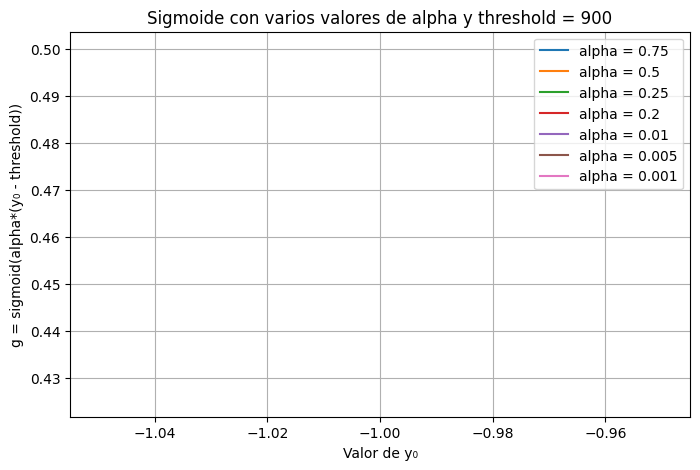

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de alpha solicitados
alphas = [0.75, 0.5, 0.25, 0.2, 0.01, 0.005, 0.001]
threshold = 900.0

# Dominio alrededor del umbral
x = np.linspace(700, 1100, 400)

plt.figure(figsize=(8, 5))
for alpha in alphas:
    y = 1 / (1 + np.exp(-alpha * (x - threshold)))
    plt.plot(x, y, label=f"alpha = {alpha}")

plt.xlabel('Valor de y₀')
plt.ylabel('g = sigmoid(alpha*(y₀ - threshold))')
plt.title('Sigmoide con varios valores de alpha y threshold = 900')
plt.grid(True)
plt.legend()
plt.show()


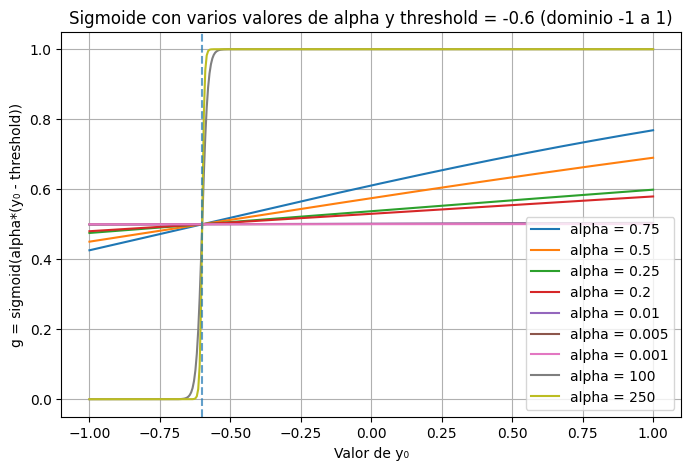

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de alpha solicitados
alphas = [0.75, 0.5, 0.25, 0.2, 0.01, 0.005, 0.001, 100, 250]
threshold = -0.6

# Dominio -1 a 1 con buena resolución
x = np.linspace(-1, 1, 400)

plt.figure(figsize=(8, 5))
for alpha in alphas:
    y = 1 / (1 + np.exp(-alpha * (x - threshold)))
    plt.plot(x, y, label=f"alpha = {alpha}")

# Línea vertical en el umbral
plt.axvline(threshold, linestyle="--", alpha=0.7)

plt.xlabel('Valor de y₀')
plt.ylabel('g = sigmoid(alpha*(y₀ - threshold))')
plt.title('Sigmoide con varios valores de alpha y threshold = -0.6 (dominio -1 a 1)')
plt.grid(True)
plt.legend()
plt.show()


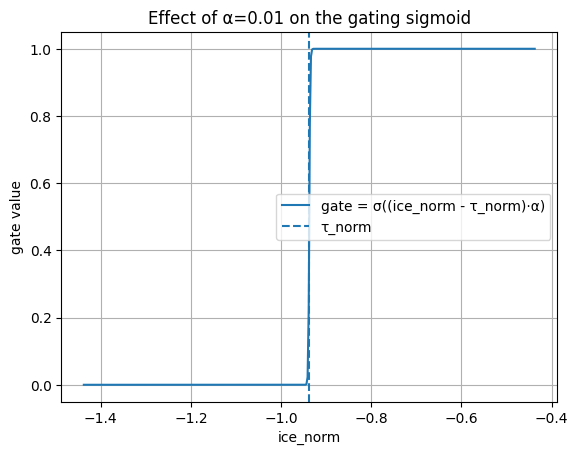

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from your model
alpha = 1000
tau_norm = -0.9375

# Generate a range of ice_norm values around the threshold
x = np.linspace(tau_norm - 0.5, tau_norm + 0.5, 400)

# Gate function
gate = 1 / (1 + np.exp(-(x - tau_norm) * alpha))

# Plot
plt.figure()
plt.plot(x, gate, label="gate = σ((ice_norm - τ_norm)·α)")
plt.axvline(tau_norm, linestyle='--', label="τ_norm")
plt.xlabel("ice_norm")
plt.ylabel("gate value")
plt.title("Effect of α=0.01 on the gating sigmoid")
plt.legend()
plt.grid(True)

plt.show()


In [1]:
def rescale(x, old_min, old_max, new_min, new_max):
    return (x - old_min) / (old_max - old_min) * (new_max - new_min) + new_min

old_min, old_max = 0, 4500
new_min, new_max = -1, 1
threshold = 900.0

rescaled_threshold = rescale(threshold, old_min, old_max, new_min, new_max)
print(rescaled_threshold)  # Salida: -0.6


-0.6
